# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 9</span>


### The Traveling Salesman Problem

The traveling salesman problem (TSP) consists of a salesman and a set of $N$ cities with positions $\vec{c}_i$. The salesman **has to visit each one of the cities starting from a certain one (e.g. the hometown) and returning to the same city**. The challenge of the problem is that the traveling salesman wants to **minimize the total length of the trip**.

Consider now the ordered sequence of cities, $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, which goes from city 1 to the n$^{th}$ city. The path that minimizes the following loss/cost function:

$$
L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|^2
$$

or 
$$
L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N) = \sum_{i=1}^{N} |\vec{x}_i-\vec{x}_{i+1}|
$$


(with $\vec{x}_{N+1}=\vec{x}_1$) is one particular permutation, P, of the ordered sequence of cities $\vec{c}_1, \vec{c}_2, \dots, \vec{c}_N$, i.e. 

$$
\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N = \vec{c}_{P1}, \vec{c}_{P2}, \dots, \vec{c}_{PN}
$$

Note also that any particular permutation of the ordered sequence of cities can be obtained from the combination of many simple permutations among pairs of cities.

We can express a possible path via a 1D vector whose elements, from the first to the last, are integers that represents the cities in the order in which the salesman would visit them; for example for $N=5$ cities one possible path is represented by the vector:

$$
\left[ 1, 3, 5, 4, 2 \right]
$$

**Alteratively**, we can express a possible path also via a configuration of a $N\times N$ 2D *Ising-like* model with the following bonds:
1. any row must have one and at most one up spin
2. any column must have one and at most one up spin,

all the other spins are down.

We can represent such a configuration with a $N\times N$ matrix whose elements are 1 (spin up) or 0 (spin down); for example, in the case of a TSP with 5 cities:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1\\
0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 1 & 0\\
0 & 0 & 1 & 0 & 0\\
\end{bmatrix}
$$

You can interpret this matrix in the following way:
- column index represents time of visit: first colum = first visit, etc.
- row index represents the ordered sequence of cities: first row = first city, etc.

the previous matrix thus refers to the following sequence:

$$
\vec{x}_1, \vec{x}_2, \vec{x}_3, \vec{x}_4, \vec{x}_5 = 
\vec{c}_{1}, \vec{c}_{3}, \vec{c}_{5}, \vec{c}_{4}, \vec{c}_{2}
$$

and thus to the following *cost* of the path:

$$
L^{(2)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3|^2 + |\vec{c}_3-\vec{c}_5|^2 + |\vec{c}_5-\vec{c}_4|^2 +
|\vec{c}_4-\vec{c}_2|^2 + |\vec{c}_2-\vec{c}_1|^2
$$

or
$$
L^{(1)}(\vec{x}_1, \dots, \vec{x}_5) = 
|\vec{c}_1-\vec{c}_3| + |\vec{c}_3-\vec{c}_5| + |\vec{c}_5-\vec{c}_4| +
|\vec{c}_4-\vec{c}_2| + |\vec{c}_2-\vec{c}_1|
$$


Note that, for this *ising-like* representation any particular permutation of the ordered sequence of cities can be obtained by a sequence of multiple pair permutations among rows and/or among columns.

**<span style="color:red">Warm suggestion: by using the 1D representation</span>** (but you can work with the representation you prefer or the one you are able to invent) ...

### Exercise 09.1

Write a C++ code to solve the TSP with a **Genetic** algorithm (GA). Note that you should invent **some** *genetic-mutation* operators and a *genetic-crossover* operator which should preserve the bonds of the problem: the salesman must visit one and only one time every city and must be back to the first city in the end of the path.

Once the data structure of your code is ready, before you start coding your genetic operators, I warmly suggest you to code the creation of the starting population and to code a **check function** that verifies if every *individual* fulfils the bonds. Then check your starting population ... and use your check function every time you create a new individual.

You have to invent also a **selection** operator. 
The fitness and thus the order of the population should be obtained from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$. Once your starting population has been ordered on a fitness basis,
you have 2 possibilities:
1. write a selection operator which obtain the probability to select an individual from $L^{(2)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$ or $L^{(1)}(\vec{x}_1, \vec{x}_2, \dots, \vec{x}_N)$
2. write a selection operator which simply uses the order in the orderd population, e.g. select the individual $j$ with the algorithm: $j=N\times int(r^p)$ where $r$ is a uniform random number $r\in[0,1)$ and $p$ a convenient exponent. 

Then you can start introducing some *genetic-mutation* operators, for example:
1. pair permutation of cities, e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 2, 4, 3, 5 \right]$ (At this point you should already have such operator ... how have you generated the starting population?).
2. shift of $+n$ position for every city in the path (this mutation/move does not change the fitness/path-length but could be helpful for ergodicity), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 4, 5, 1, 2, 3 \right] $ for a $+2$ shift
3. shift of $+n$ positions for $m$ contiguous cities (given the presence of the previous operator, you can avoid mutations that require usage of periodic boundary conditions), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 5, 2, 3 \right] $ for a $+2$ shift of the second and third cities.
4. permutation among $m$ contiguous cities with other (different!) $m$ contiguous cities ($m<N/2$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 4, 5, 3, 1, 2 \right] $ for a permutation of the first 2 cities with the last 2.
5. inversion of the order in which they appear in the path of $m$ cities ($m \le N$), e.g. $\left[ 1, 2, 3, 4, 5 \right] \to \left[ 1, 4, 3, 2, 5 \right]$ for the inversion of the cities from 2 to 4.

Every mutation will have its probability, $p^{(i)}_m$ to be called and typically $p^{(i)}_m < 10\%$, but before to include crossover you can check if the GA is able to perform a good *random search* using only mutation operators (in this case $p^{(i)}$ could be higher than in the previous suggestion).

At this point you can add a *crossover* operator (that fulfils the bods and that you will call with probability $p^{(i)}_c > 50\%$):

given a selected mother and father, e.g. 
$$
\left[ 1, 2, 3, 4, 5 \right]\\
\left[ 1, 5, 4, 3, 2 \right] 
$$
1. cut their paths at the same position:
$$
\left[ 1, 2, 3 | 4, 5 \right]\\
\left[ 1, 5, 4 | 3, 2 \right] 
$$
2. conserve the first part of the paths:
$$
\left[ 1, 2, 3 | X, Y \right]\\
\left[ 1, 5, 4 | X, Y \right] 
$$
3. complete the paths with the missing cities adding them in the **order** in which they appear in the consort:
$$
\left[ 1, 2, 3 | 5, 4 \right]\\
\left[ 1, 5, 4 | 2, 3 \right] 
$$

Here you are: you have two sons that you can add to the new generation ... and so on!

Apply your code to the optimization of a path among 

- 30 cities randomly placed **on** a circumference
- 30 cities randomly placed **inside** a square

Show your results via:

- a picture of $L^{(2)}$ (or $L^{(1)}$) of the best path and of $\langle L^{(2)}\rangle$ (or $\langle L^{(1)}\rangle$), averaged on the best half of the population, as a function of the iterations/generations of your algorithm
- a picture of the best path

# Genetic Algorithms #
----------

## Principle ##

The purpose of this lab is find a solution to the traveling salesman problem with a genetic algorithm. As the name suggests, this method is losely inspired by evolutionary principles, such as mutations, survival of the fittest, etc. Here is how it works: a candidate solution (tour at which the cities are visited) is encoded as a **chromosome**. We then select and combine the best chromosomes (sometimes even adding a mutation) to get an even better candidates.

This process allows us to find <em>good solution</em> in fast and efficient way. Note that for dimensions higher than 2, it cannot be proven that the TSP has a unique solution.


## Why is this efficient? ##

When we are searching a solution for the TSP, we are essentially exploring many solutions to select the best one. Genetic algorithms can fully be appreciated when compared to brute force exploration. A set of 30 cities represents $N=30! \approx 10^{32}$ possible tours. By contrast, the genetic algorithm we are about to implement needs to explore "only" 3000 generations of 20'000 tours each (i.e. a search space of the order of $10^8$). This might seem a lot at first glance, but put taken into context it corresponds to an astonishingly small fraction of about $10^{-22}\%$ of the total search space N.

# One-Dimensional TSP #
------------

## Cities Positions ##

The following script generates cities randomly placed along a circle and saves the respective positions in a file (```linear_cities_database.dat```). I've added a sort of "accept-reject" logic to the angular positions creation, so that the generated cities do not overlap and are well enough separated.

This placement will serve as a **reference to compute the cost** of each tour. In fact, once we know the positions we can calculate the total distance traveled to visit all the cities.

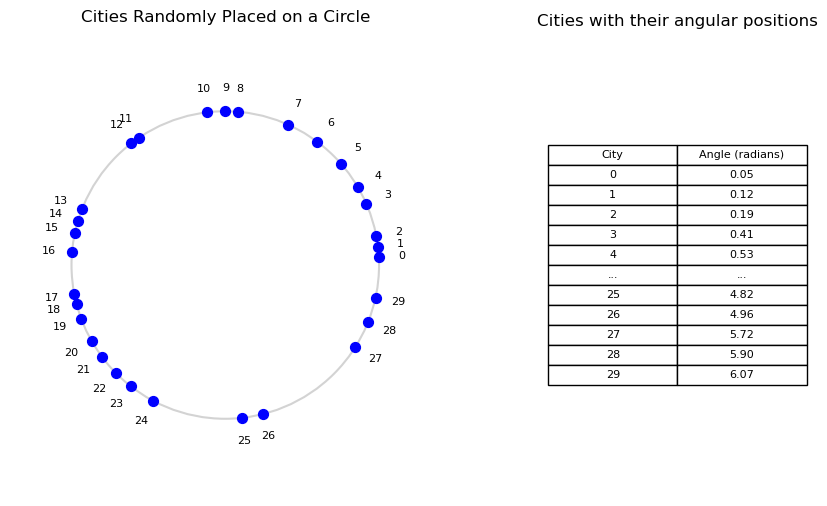

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

random.seed(1234)
number_of_cities = 30
min_gap = 0.05

angular_positions = []

# Every time the random generator proposes a cadidate angular position we check if this position is far enough
# from the other positions. If so we reject the candidate, if not we accept it.
# The loop continues until all positions have been created
while len(angular_positions) < number_of_cities:
    candidate = round(random.uniform(0, 2*np.pi), 2)
    if all(abs(candidate - a) > min_gap for a in angular_positions):
        angular_positions.append(candidate)

sorted_angular_positions = sorted(angular_positions)
cities_database = np.column_stack((np.arange(number_of_cities), sorted_angular_positions))
#print(cities_database)

# ----- Saving the database into a .dat file
np.savetxt(
    "./TSP_Source/Data/linear_cities_database.dat",
    cities_database,
    fmt=['%d', '%.2f'],
    delimiter=",",     
    header="City_label,Angle_radians",
    comments=''
)

radius = 1.0
x = radius * np.cos(sorted_angular_positions)
y = radius * np.sin(sorted_angular_positions)

# --- Visualization setup ---
fig, (ax_circle, ax_table) = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(wspace=0.4)  # spacing between circle and table

# --- Circle plot ---
ax_circle.set_aspect('equal', adjustable='box')
circle = plt.Circle((0, 0), radius, color='lightgrey', fill=False, linewidth=1.5)
ax_circle.add_artist(circle)
ax_circle.scatter(x, y, color='blue', s=50, zorder=3)

# Add labels near each point
for i in range(number_of_cities):
    ax_circle.text(x[i] * 1.15, y[i] * 1.15, str(i), ha='center', va='center', fontsize=8)

# Clean up circle plot appearance
ax_circle.set_xlim(-radius * 1.4, radius * 1.4)
ax_circle.set_ylim(-radius * 1.4, radius * 1.4)
ax_circle.axis('off')
ax_circle.set_title("Cities Randomly Placed on a Circle", pad=20)

# --- Prepare truncated table data ---
# Shows the first 'head' and last 'tail' rows, with dots in the middle.
def truncate_table(data, head=5, tail=5):
    if len(data) <= head + tail:
        return data  # no need to truncate
    return np.vstack([
        data[:head],
        [["...", "..."]],
        data[-tail:]
    ])

table_data_full = [[int(row[0]), f"{row[1]:.2f}"] for row in cities_database]
table_data = truncate_table(np.array(table_data_full, dtype=object))
column_labels = ["City", "Angle (radians)"]

# --- Create the table ---
table = ax_table.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)
ax_table.set_title('Cities with their angular positions')
ax_table.axis('off')

plt.show()

## Workflow ##

To find _a_ solution to the traveling salesman's problem using a genetic algorithm, we will follow this general workflow:

1. Generate an initial **valid** population
2. Generate two offsprings from parents of the initial population / apply some mutation to a restricted number
3. Check that the offsprings are valid candidates, if not apply some sort of correction
4. Select a percentage of surviving offsprings so that the population number remains constant
5. Repeat 1-4 until the cost $L$ is optimzed

## Initial Population ##

In the case of the one-dimensional TSP we are lucky to know ahead the best and only solution to the problem: it is trivially the order at which the cities appear on the line (like stations on a train track). Note that for higher dimensions it is not always possible to find <em>the</em> best solution to the TSP. In fact, it is common to accept a "good enough" solution. Nonetheless we can use this knowledge to measure our genetic algorithm performance by checking if the runtime cost approaches a reference cost.

I've decided to use the tools available in the c++ standard library (specifically vectors and permutation tools) to **directly generate a population of valid tours** (instead of creating tours and then checking if they are valid). I took the same approach when creating offsprings.

The member function of the class ```GeneticAlgorithm``` responsible to create a new population is:

`
std::vector<std::vector<int>> GeneticAlgorithm::generatePopulation(int numCities, int populationSize)
`

It returns a vector of vectors in the form:

$$
\begin{aligned}
\mathbf{v}_1 &= (c_0, c_4, \ldots, c_7, c_0) \\
\mathbf{v}_2 &= (c_0, c_{24}, \ldots, c_{27}, c_0) \\
\mathbf{v}_3 &= (c_0, c_{11}, \ldots, c_{5}, c_0) \\
&\;\;\vdots \\
\mathbf{v}_{\text{populationSize}} &= (c_0, c_{12}, \ldots, c_{9}, c_0)
\end{aligned}
$$
<br>

Under the hood, each tour is created as follows. First we generate an empty vector of size ```numCities``` +1 (the hometown is counted twice). We fill the first and last element with the hometown (default: 0). We then generate a list ```remainingCities``` of integers ranging from 1 to ```numCities``` - 1. We randomly shuffle the list of remaining cities and used that scrabled list to fill the rest of the tour's elements. This ensures us that each tour of the population is a valid tour. This whole process relies on c++ std library tools.

## "Roulette Wheel" Selection Operator ##

The selection operator I use to select the fittest pairs for crossover is called the "roulette wheel selector". It allows the algorithm to pick two pairs randomly but also proportionally to their cost. To see how it works, we can imagine a roulette sliced in sectors each representing a particular tour (chromosome). Tours with lower costs have bigger sectors, so that when we randomly choose a tour by "spinnig the wheel" we have a higher probability of stopping the wheel at a big sector.

This allows us to select with higher probability tours with lower cost. At the same time, it still allows to retain some diversity.

## Crossover Operator ##

The next step consists of generating the next population from the fittest chromosomes. To do so, we are "crossing over" two parents from the fittest population to generate two offsprings for each couple of parents (so that the total population number remains constant).

We start taking the last three cities (before the hometown) $(n-4, n-3, n-2, n-1)$ of parent 1. We make a copy of parent 2 ommiting $(n-4, n-3, n-2, n-1)$. Finally we append $(n-4, n-3, n-2, n-1)$ to that copy. The result is child 1. We go through the same process again but starting with parent 2.

That way, we generate two valid offsprings.

$$
\begin{aligned}
\text{Parent 1: } & [H,\, a,\, b,\, c,\, d,\, e,\, f,\, g,\, H] \\
\text{Parent 2: } & [H,\, d,\, f,\, a,\, g,\, b,\, e,\, c,\, H] \\[6pt]
\text{Segment from Parent 1: } & (e,\, f,\, g) \\[6pt]
\text{Child 1: } & [H,\, d,\, a,\, g,\, b,\, c,\, e,\, f,\, g,\, H] \\[2pt]
\text{(Parent 2’s order without } e, f, g \text{, then append } e, f, g) \\[10pt]
\text{Segment from Parent 2: } & (b,\, e,\, c) \\[6pt]
\text{Child 2: } & [H,\, a,\, b,\, c,\, d,\, e,\, f,\, g,\, H] \\[2pt]
\text{(Parent 1’s order without } b, e, c \text{, then append } b, e, c)
\end{aligned}
$$

### Plotting the cost against tour index: ###

Reference (Optimal) Cost = 6.28319


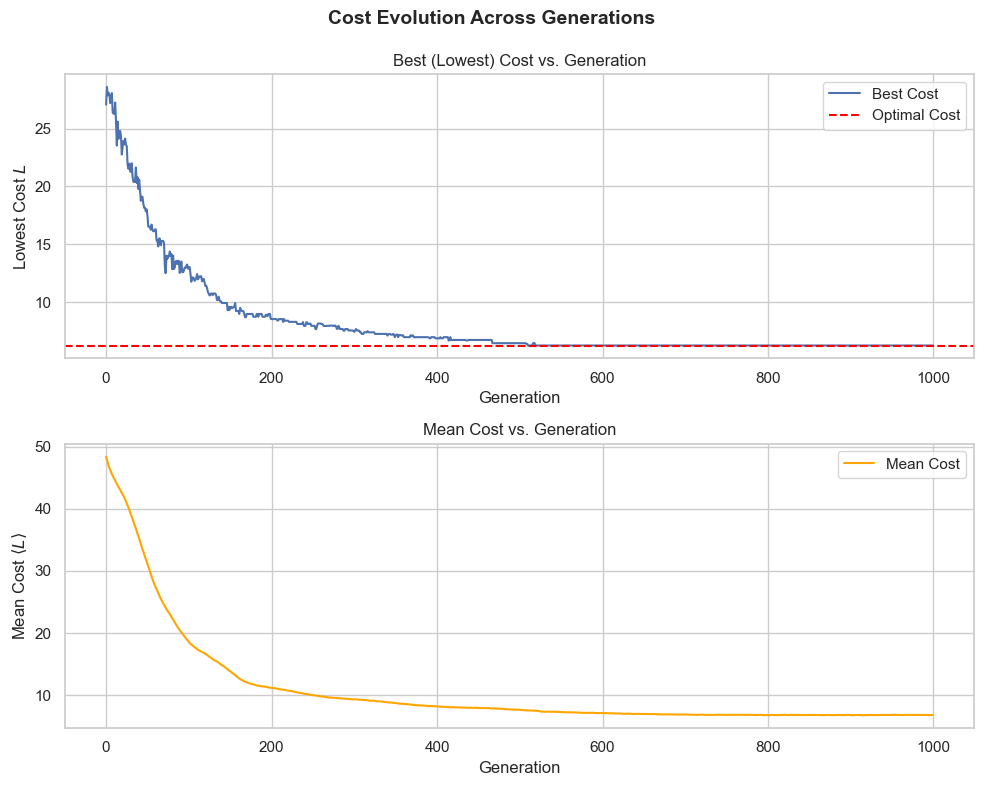

In [2]:
# Saving the reference value
with open("./TSP_Source/Data_out/cost_evolution.dat") as f:
    first_line = f.readline().strip()
ref_value = float(first_line.split(",")[1])
print("Reference (Optimal) Cost =", ref_value)

df = pd.read_csv("./TSP_Source/Data_out/cost_evolution.dat", skiprows=1, sep=",")
#print(df.head())

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2,1, figsize=(10,8), sharex=False)

sns.lineplot(ax=axes[0], x="Generation", y="BestCost", label="Best Cost", data=df)
axes[0].axhline(y=ref_value, color="red", linestyle="--", label="Optimal Cost")
axes[0].set_title("Best (Lowest) Cost vs. Generation")
axes[0].set_ylabel(r'Lowest Cost $L$')
axes[0].legend(loc="best")

sns.lineplot(ax=axes[1], x="Generation", y="MeanCost",  label="Mean Cost", data=df, color="orange")
axes[1].set_title("Mean Cost vs. Generation")
axes[1].set_ylabel(r'Mean Cost $\langle L \rangle$')
axes[1].set_xlabel("Generation")
axes[1].legend(loc="best")

fig.suptitle("Cost Evolution Across Generations", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(top=0.9)

plt.show()

## Visualizing Points on a Circle ##
---------------

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- Load station positions ---
data_positions = np.loadtxt(
    "./TSP_Source/Data/linear_cities_database.dat",
    delimiter=',',
    skiprows=1,
    usecols=(0,1)
)

positions = data_positions[:, 1]
n_points = positions.size

# Map points to angles and Cartesian coordinates
min_pos, max_pos = positions.min(), positions.max()
angles = 2 * np.pi * (positions - min_pos) / (max_pos - min_pos)
x = np.cos(angles)
y = np.sin(angles)

# --- Settings ---
generations = [1, 100, 1000, 3000]
header_rows = 1  # header lines in shortest_tours.dat

# --- Function to create simple animation GIF ---
def create_simple_tour_gif(gen):
    skip_rows = header_rows + (gen - 1)
    tour = np.loadtxt(
        "./TSP_Source/Data_out/shortest_tours.dat",
        delimiter=',',
        skiprows=skip_rows,
        max_rows=1,
        dtype=int
    )
    if tour.min() == 1:
        tour = tour - 1  # convert to 0-based index

    tour_x = x[tour]
    tour_y = y[tour]

    # Set up figure
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x, y, color='blue', s=100, zorder=2)
    for i, (xx, yy) in enumerate(zip(x, y)):
        ax.text(xx*1.08, yy*1.08, str(i), ha='center', va='center')
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    ax.add_artist(circle)
    ax.axis('equal')
    ax.axis('off')

    # Line and moving marker
    line, = ax.plot([], [], color='red', linewidth=2, zorder=1)
    marker, = ax.plot([], [], 'ro', markersize=8)

    # Animation update function
    def update(frame):
        line.set_data(tour_x[:frame+1], tour_y[:frame+1])
        marker.set_data([tour_x[frame]], [tour_y[frame]])
        return line, marker

    ani = FuncAnimation(fig, update, frames=len(tour_x), interval=500, blit=False)
    ani.save(f"./Images/salesman_best_tour_generation_{gen}.gif", writer='pillow', fps=2)
    plt.close(fig)

# --- Generate GIFs for all selected generations ---
for gen in generations:
    create_simple_tour_gif(gen)

## Visualizing the Salesman's Journey ##
-------------

It is interesting to see the salesman journey to visually check if there is an improvement over the generations. Such visualization can be seen in the gifs saved in the ```Images/``` folder. Note: the red lines help to see what cities does the traveler visit in sequence. It is not the *actual* path of the traveler. In fact, in this model he is constrained to stay on the circle (but that would make the visualization less intuitive).

Far from being superflous, visualizing the results can be very important to confirm our results. We can observe that, despite minimizing the cost to a near optimal value, the "best tour" is actually *not* optimal:

```(0,4,6,8,10,12,14,16,18,21,24,26,28,27,25,23,22,20,19,17,15,13,11,9,7,5,3,2,1,0)```

After a bit of research, I found that one reason to this anomaly could be due to bad discrete rounding of distances, especially if some cities are close to each other, so that small differences actually disappear.

# Two-Dimensional TSP #
------------

## Generating Random Cities ##

Generating random $(x,y)$ positions uniformly distributed on a plane is much simpler. We simply generate uniformly distributed random coordinates and label the cities in the order as they appear. The downside of this case is that we don't have an <em>a priori</em> knowledge of the best tour anymore. So initially the salesman visits the cities in the order in which they were first generated.

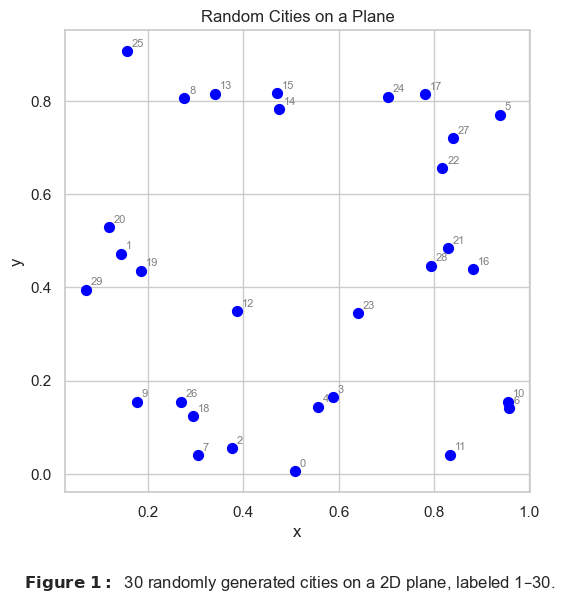

In [4]:
number_of_cities = 30

# Generate 30 random points (x, y) in the unit square [0,1] x [0,1]
cities = [(round(random.uniform(0, 1), 4), round(random.uniform(0, 1), 4)) 
          for _ in range(number_of_cities)]

# Convert to NumPy array
cities_array = np.array(cities)  # shape (30, 2)

# Combine city index with coordinates
plane_cities_database = np.column_stack((np.arange(number_of_cities), cities_array))

#print(plane_cities_database)

# ----- Saving the database into a .dat file
np.savetxt(
    "./TSP_Source/Data/plane_cities_database.dat",
    plane_cities_database,
    fmt=['%d', '%.2f', '%.2f'], # fmt = "format" (d = integer, f = float, ..)
    delimiter=",",     
    header="City_label,x_position,y_position",
)

labels = plane_cities_database[:,0]
x_coords = plane_cities_database[:,1]
y_coords = plane_cities_database[:,2]

plt.figure(figsize=(6,6))
plt.scatter(x_coords,y_coords,color="blue",s=50)

# Add labels to each point
for i, label in enumerate(labels):
    plt.text(x_coords[i]+0.01, y_coords[i]+0.01, str(int(label)), fontsize=8, color='grey')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Random Cities on a Plane")
plt.grid(True)

# Add explanatory text below the plot
plt.figtext(
    0.5, -0.05, 
    r"$\mathbf{Figure\ 1:}$  30 randomly generated cities on a 2D plane, labeled 1–30.", 
    ha="center", fontsize=12
)

plt.show()

## Plotting the best tour ##

In [5]:
filename = "./TSP_Source/Data_out/best_tours_two_dimensional.dat"

with open(filename, "r") as f:
    lines = f.readlines()

# Skip empty lines and header
lines = [line.strip() for line in lines if line.strip()]
last_line = lines[-1]

#print("Last line in file:")
#print(last_line)

Generation: 900
Tour: [0, 2, 7, 18, 26, 9, 12, 19, 29, 1, 20, 25, 8, 13, 15, 14, 24, 17, 5, 27, 22, 21, 28, 16, 10, 6, 11, 23, 3, 4, 0]


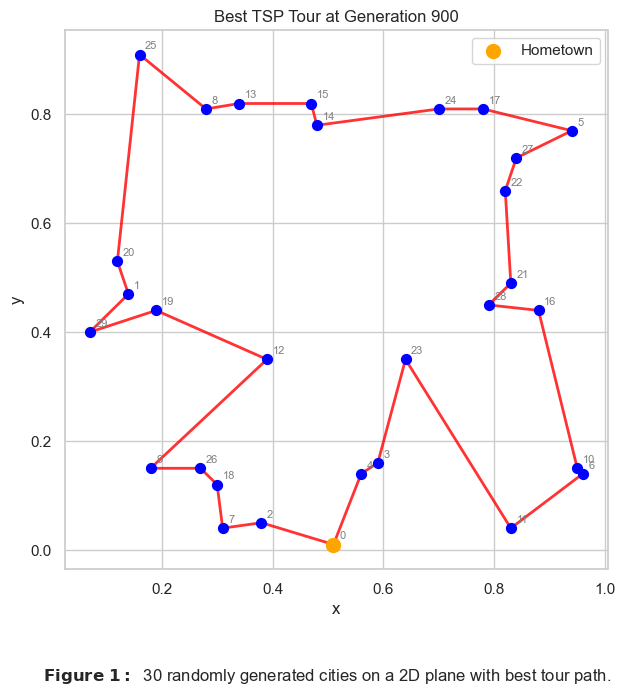

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

filename = "./TSP_Source/Data_out/best_tours_two_dimensional.dat"

with open(filename, "r") as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

last_line = lines[-1]  # e.g. "900,0,2,7,...,0,"
parts = last_line.split(",")

generation = int(parts[0])
tour = [int(x) for x in parts[1:] if x.strip().isdigit()]

print(f"Generation: {generation}")
print(f"Tour: {tour}")

number_of_cities = 30

plane_cities_database = np.loadtxt(
    "./TSP_Source/Data/plane_cities_database.dat",
    delimiter=",",
    skiprows=1
)

labels = plane_cities_database[:, 0]
x_coords = plane_cities_database[:, 1]
y_coords = plane_cities_database[:, 2]

plt.figure(figsize=(7, 7))
plt.scatter(x_coords, y_coords, color="blue", s=50, zorder=2)

for i, label in enumerate(labels):
    plt.text(x_coords[i] + 0.01, y_coords[i] + 0.01, str(int(label)),
             fontsize=8, color='grey')

tour_x = [x_coords[i] for i in tour]
tour_y = [y_coords[i] for i in tour]

plt.plot(tour_x, tour_y, color="red", linewidth=2, alpha=0.8, zorder=1)
plt.scatter(tour_x[0], tour_y[0], color="orange", s=100, label="Hometown", zorder=3)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Best TSP Tour at Generation {generation}")
plt.grid(True)
plt.legend()

plt.figtext(
    0.5, -0.05,
    r"$\mathbf{Figure\ 1:}$  30 randomly generated cities on a 2D plane with best tour path.",
    ha="center", fontsize=12
)

plt.show()